In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.model_selection import RandomizedSearchCV, learning_curve, ShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    balanced_accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

In [13]:
# === 1. Load data ===
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")


In [14]:
# === 2. Feature engineering ===
for df in [train_df, test_df]:

    if "timestamp" in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"])
        df["hour"] = df["timestamp"].dt.hour
        df["dayofweek"] = df["timestamp"].dt.dayofweek

    if "gs_lead1" in df.columns:
        gs_lead1_actual = test_df["gs_lead1"].copy()
        df.drop(columns=["gs_lead1"], inplace=True)

    df["excess_demand"] = df["AAR_CAPACITY"] - df["COUNT_ARR_SCH"]
    df["vissibility_demand"] = df["excess_demand"] / (df["visibility"] + 0.0001)
    df["ceiling_sum"] = df["cld<500"] + df["cld 500-999"] + df["cld 1000-3000"]

    if df is test_df and "gs_cause_lead1" in df.columns:
        cause_col = df["gs_cause_lead1"].copy()
        df.drop(columns=["gs_cause_lead1"], inplace=True)

    df.drop(columns=["COUNT_ARR_SCH"], inplace=True)
    df.drop(columns=["AIRPORT","gs_lag1","gs_start","gs_duration","gs_duration_lead1","gdp_lead1","gs_lead2","gdp_lead1"], inplace=True)
    df.drop(columns=["SNGS", "COUNT_ARR_ACT", "AAR_EFF_lead1", "AAR_EFF_lead2","AAR_EFF_lead3","AAR_EFF_lead4","AAR_EFF_lead5","AAR_EFF_lead6","AAR_EFF_lead7","AAR_EFF_lead8"], inplace=True)




In [15]:
# === 3. Numeric only (NO row-dropping) ===
train_df = train_df.select_dtypes(include=np.number)
test_df  = test_df.select_dtypes(include=np.number)



# Drop rows only if target is missing (train) / required label missing (test)
train_df = train_df.dropna(subset=["gs"])
test_df  = test_df.dropna(subset=["gs"])

# Impute remaining missing values using TRAIN statistics
medians = train_df.median(numeric_only=True)
train_df = train_df.fillna(medians)
test_df  = test_df.fillna(medians)


In [16]:
# === 4. Split ===
X_train_unbalanced = train_df.drop(columns="gs")
y_train_unbalanced = (train_df["gs"] > 0).astype(int)

X_test = test_df.drop(columns="gs")
y_test = (test_df["gs"] > 0).astype(int)
"""
df_train = X_train_unbalanced.copy()
df_train["gs"] = y_train_unbalanced

df_gs = df_train[df_train["gs"] == 1]
df_no_gs = df_train[df_train["gs"] == 0].sample(frac=0.4, random_state=42)

df_balanced = pd.concat([df_gs, df_no_gs]).sample(frac=1, random_state=42)

X_train = df_balanced.drop(columns="gs")
y_train = df_balanced["gs"]
"""
X_train = X_train_unbalanced.copy()
y_train = y_train_unbalanced.copy()

In [17]:

# === Feature transforms ===
X_train["wind_gust_squared"] = X_train["wind_gust"] ** 2
X_test["wind_gust_squared"] = X_test["wind_gust"] ** 2

for feature in ["cross_winds", "headtail_winds", "wind_speed"]:
    if feature in X_train.columns:
        X_train[f"{feature}_log"] = np.log1p(X_train[feature])
        X_test[f"{feature}_log"] = np.log1p(X_test[feature])


# After feature transforms
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test  = X_test.replace([np.inf, -np.inf], np.nan)

In [18]:
# Impute using train medians (AFTER you create all new features)
med = X_train.median(numeric_only=True)
X_train = X_train.fillna(med)
X_test  = X_test.fillna(med)



In [19]:
# === Base Random Forest ===
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
    min_samples_split=10
)
rf_model.fit(X_train, y_train)
print("Training rows:", X_train.shape[0])
print("Training columns:", X_train.shape[1])
print("Positive rate:", y_train.mean())
print("X_train shape:", X_train.shape)
print("Total NaNs in X_train:", X_train.isna().sum().sum())
print("Cols with NaNs (top 20):")
print(X_train.isna().sum().sort_values(ascending=False).head(20))



Training rows: 42038
Training columns: 394
Positive rate: 0.04902707074551596
X_train shape: (42038, 394)
Total NaNs in X_train: 0
Cols with NaNs (top 20):
AAR_EFFICIENCY    0
VCTS_fcst6        0
VCTS_fcst4        0
VCTS_fcst3        0
VCTS_fcst2        0
VCTS_fcst1        0
TS_fcst8          0
TS_fcst7          0
TS_fcst6          0
TS_fcst5          0
TS_fcst4          0
TS_fcst3          0
TS_fcst2          0
TS_fcst1          0
TSRA_fcst8        0
TSRA_fcst7        0
TSRA_fcst6        0
TSRA_fcst5        0
TSRA_fcst4        0
TSRA_fcst3        0
dtype: int64


In [20]:
# === Scaling ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("NaNs in X_train_scaled:", np.isnan(X_train_scaled).sum())
print("Infs in X_train_scaled:", np.isinf(X_train_scaled).sum())



NaNs in X_train_scaled: 0
Infs in X_train_scaled: 0


In [21]:
# === SMOTE ===
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)


In [22]:

# === RF tuning ===
param_dist = {
    "n_estimators": [100, 200],
    "max_depth": [5, None],
    "max_features": [None],
    "min_samples_split": [10],
    "min_samples_leaf": [1],
    "bootstrap": [True, False]
}

search = RandomizedSearchCV(
    rf_model,
    param_dist,
    n_iter=10,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1
)
search.fit(X_train, y_train)
best_rf = search.best_estimator_

# === XGBoost ===
xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 6, 10],
    "learning_rate": [0.01, 0.1, 0.3],
    "subsample": [0.7, 1.0]
}

xgb = XGBClassifier(eval_metric="logloss", random_state=42)
xgb_search = RandomizedSearchCV(xgb, xgb_params, n_iter=10, cv=3, scoring="f1", n_jobs=-1)
xgb_search.fit(X_train_res, y_train_res)
best_xgb = xgb_search.best_estimator_

# === KNN ===
knn_params = {"n_neighbors": [3,5,7,9], "weights": ["uniform", "distance"]}
knn = KNeighborsClassifier()
knn_search = RandomizedSearchCV(knn, knn_params, n_iter=6, cv=3, scoring="f1", n_jobs=-1)
knn_search.fit(X_train_res, y_train_res)
best_knn = knn_search.best_estimator_

In [23]:
# === Stacking ===
stacking_clf = StackingClassifier(
    estimators=[
        ("rf", best_rf),
        ("knn", best_knn),
        ("xgb", best_xgb)
    ],
    final_estimator=LogisticRegression(class_weight="balanced", max_iter=1000),
    cv=5,
    n_jobs=-1
)

stacking_clf.fit(X_train_res, y_train_res)


StackingClassifier(cv=5,
                   estimators=[('rf',
                                RandomForestClassifier(class_weight='balanced',
                                                       max_features=None,
                                                       min_samples_split=10,
                                                       n_estimators=200,
                                                       n_jobs=-1,
                                                       random_state=42)),
                               ('knn',
                                KNeighborsClassifier(n_neighbors=3,
                                                     weights='distance')),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              cols...
                                              interaction_constraints=None,
                                              learning_rate=0.1, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None, max_depth=10,
                                              max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=100, n_jobs=None,
                                              num_parallel_tree=None, ...))],
                   final_estimator=LogisticRegression(class_weight='balanced',
                                                      max_iter=1000),
                   n_jobs=-1)

In [24]:
# === Predictions ===
from sklearn.metrics import precision_recall_curve
import numpy as np

y_proba = stacking_clf.predict_proba(X_test_scaled)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("Best validation F1:", f1_scores[best_idx])

y_pred = (y_proba >= best_threshold).astype(int)

Best threshold: 0.2339528099819875
Best validation F1: 0.6320166270706602


In [25]:
# === Evaluation ===
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("Balanced Accuracy:", balanced_acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)
print("Positive rate in test set:", y_test.mean())

[[9852  127]
 [ 227  304]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      9979
           1       0.71      0.57      0.63       531

    accuracy                           0.97     10510
   macro avg       0.84      0.78      0.81     10510
weighted avg       0.96      0.97      0.96     10510


Accuracy: 0.9663177925784967
Balanced Accuracy: 0.7798889909865331
Precision: 0.7053364269141531
Recall: 0.5725047080979284
F1: 0.632016632016632
ROC-AUC: 0.9504077206200818
PR-AUC: 0.6758436779933079
Positive rate in test set: 0.05052331113225499


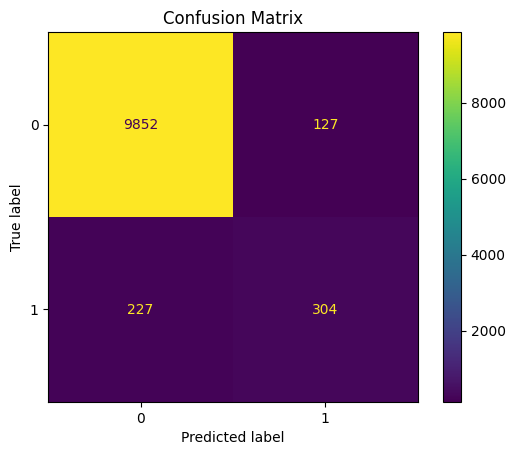

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()

AVG_GATE_ARR_DLY             0.287772
gdp_lead2                    0.079042
COUNT_ARR_SCH_lead1          0.063462
gdp                          0.046571
gs_duration_lead2            0.041395
excess_demand                0.021368
COUNT_ARR_SCH_lag1           0.020296
COUNT_ARR_SCH_lead2          0.013576
dew_point_temperature        0.012798
COUNT_ARR_ACT_lag2           0.010932
air_pressure_at_sea_level    0.010898
northward_wind               0.010671
vissibility_demand           0.009530
air_temperature              0.008963
eastward_wind                0.008634
dtype: float64


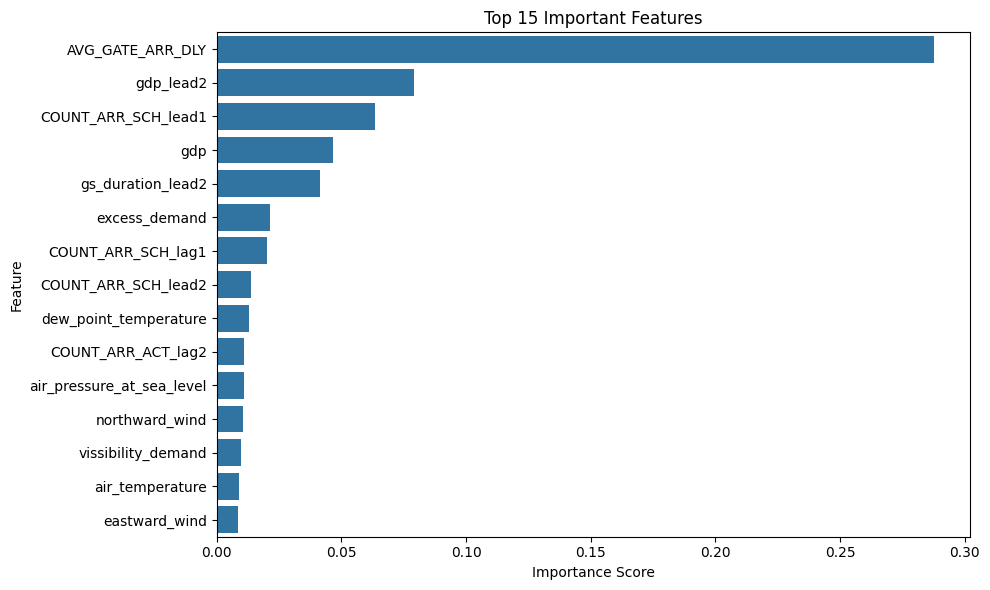

In [27]:

# === Feature importance ===
"""feat_imp = pd.Series(best_rf.feature_importances_, index=X_train.columns)
top_feats = feat_imp.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=top_feats.values, y=top_feats.index)
plt.title("Top 15 Important Features")
plt.tight_layout()
plt.show()"""

feat_imp = pd.Series(best_rf.feature_importances_, index=X_train.columns)
top_feats = feat_imp.sort_values(ascending=False).head(15)

print(top_feats)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_feats.values, y=top_feats.index)
plt.title("Top 15 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [28]:
import joblib

joblib.dump(stacking_clf, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X_train.columns.tolist(), "features.pkl")

['features.pkl']

In [30]:


# Save confusion matrix
cm = confusion_matrix(y_test, y_pred)
joblib.dump(cm, "conf_matrix.pkl")

print("Saved model.pkl, scaler.pkl, features.pkl, and conf_matrix.pkl")

Saved model.pkl, scaler.pkl, features.pkl, and conf_matrix.pkl
